In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Thu Oct 17 15:40:19 2024
@author: marriyapillais
"""

'\nCreated on Thu Oct 17 15:40:19 2024\n@author: marriyapillais\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from scipy.optimize import minimize, curve_fit, show_options
from functools import partial

In [4]:
parameter = pd.read_csv("../data/processed/inc_proj_parameters.csv")
bau_data = pd.read_csv("../data/results/BAU_MSW_updated.csv", index_col = 0)

## REC scenario

### Data Structure

In [5]:
bau_data["Scenario"] = "BAU"  
bau_data.loc[bau_data["TIME"] <= 2021, "Scenario"] = "OBS"

In [6]:
bau_data.reset_index(drop=True, inplace= True)
rec_data = bau_data.loc[bau_data["TIME"]>=2022].copy()
rec_data['Scenario']='REC'

In [7]:
from functions import get_rec_data

### Plotting 

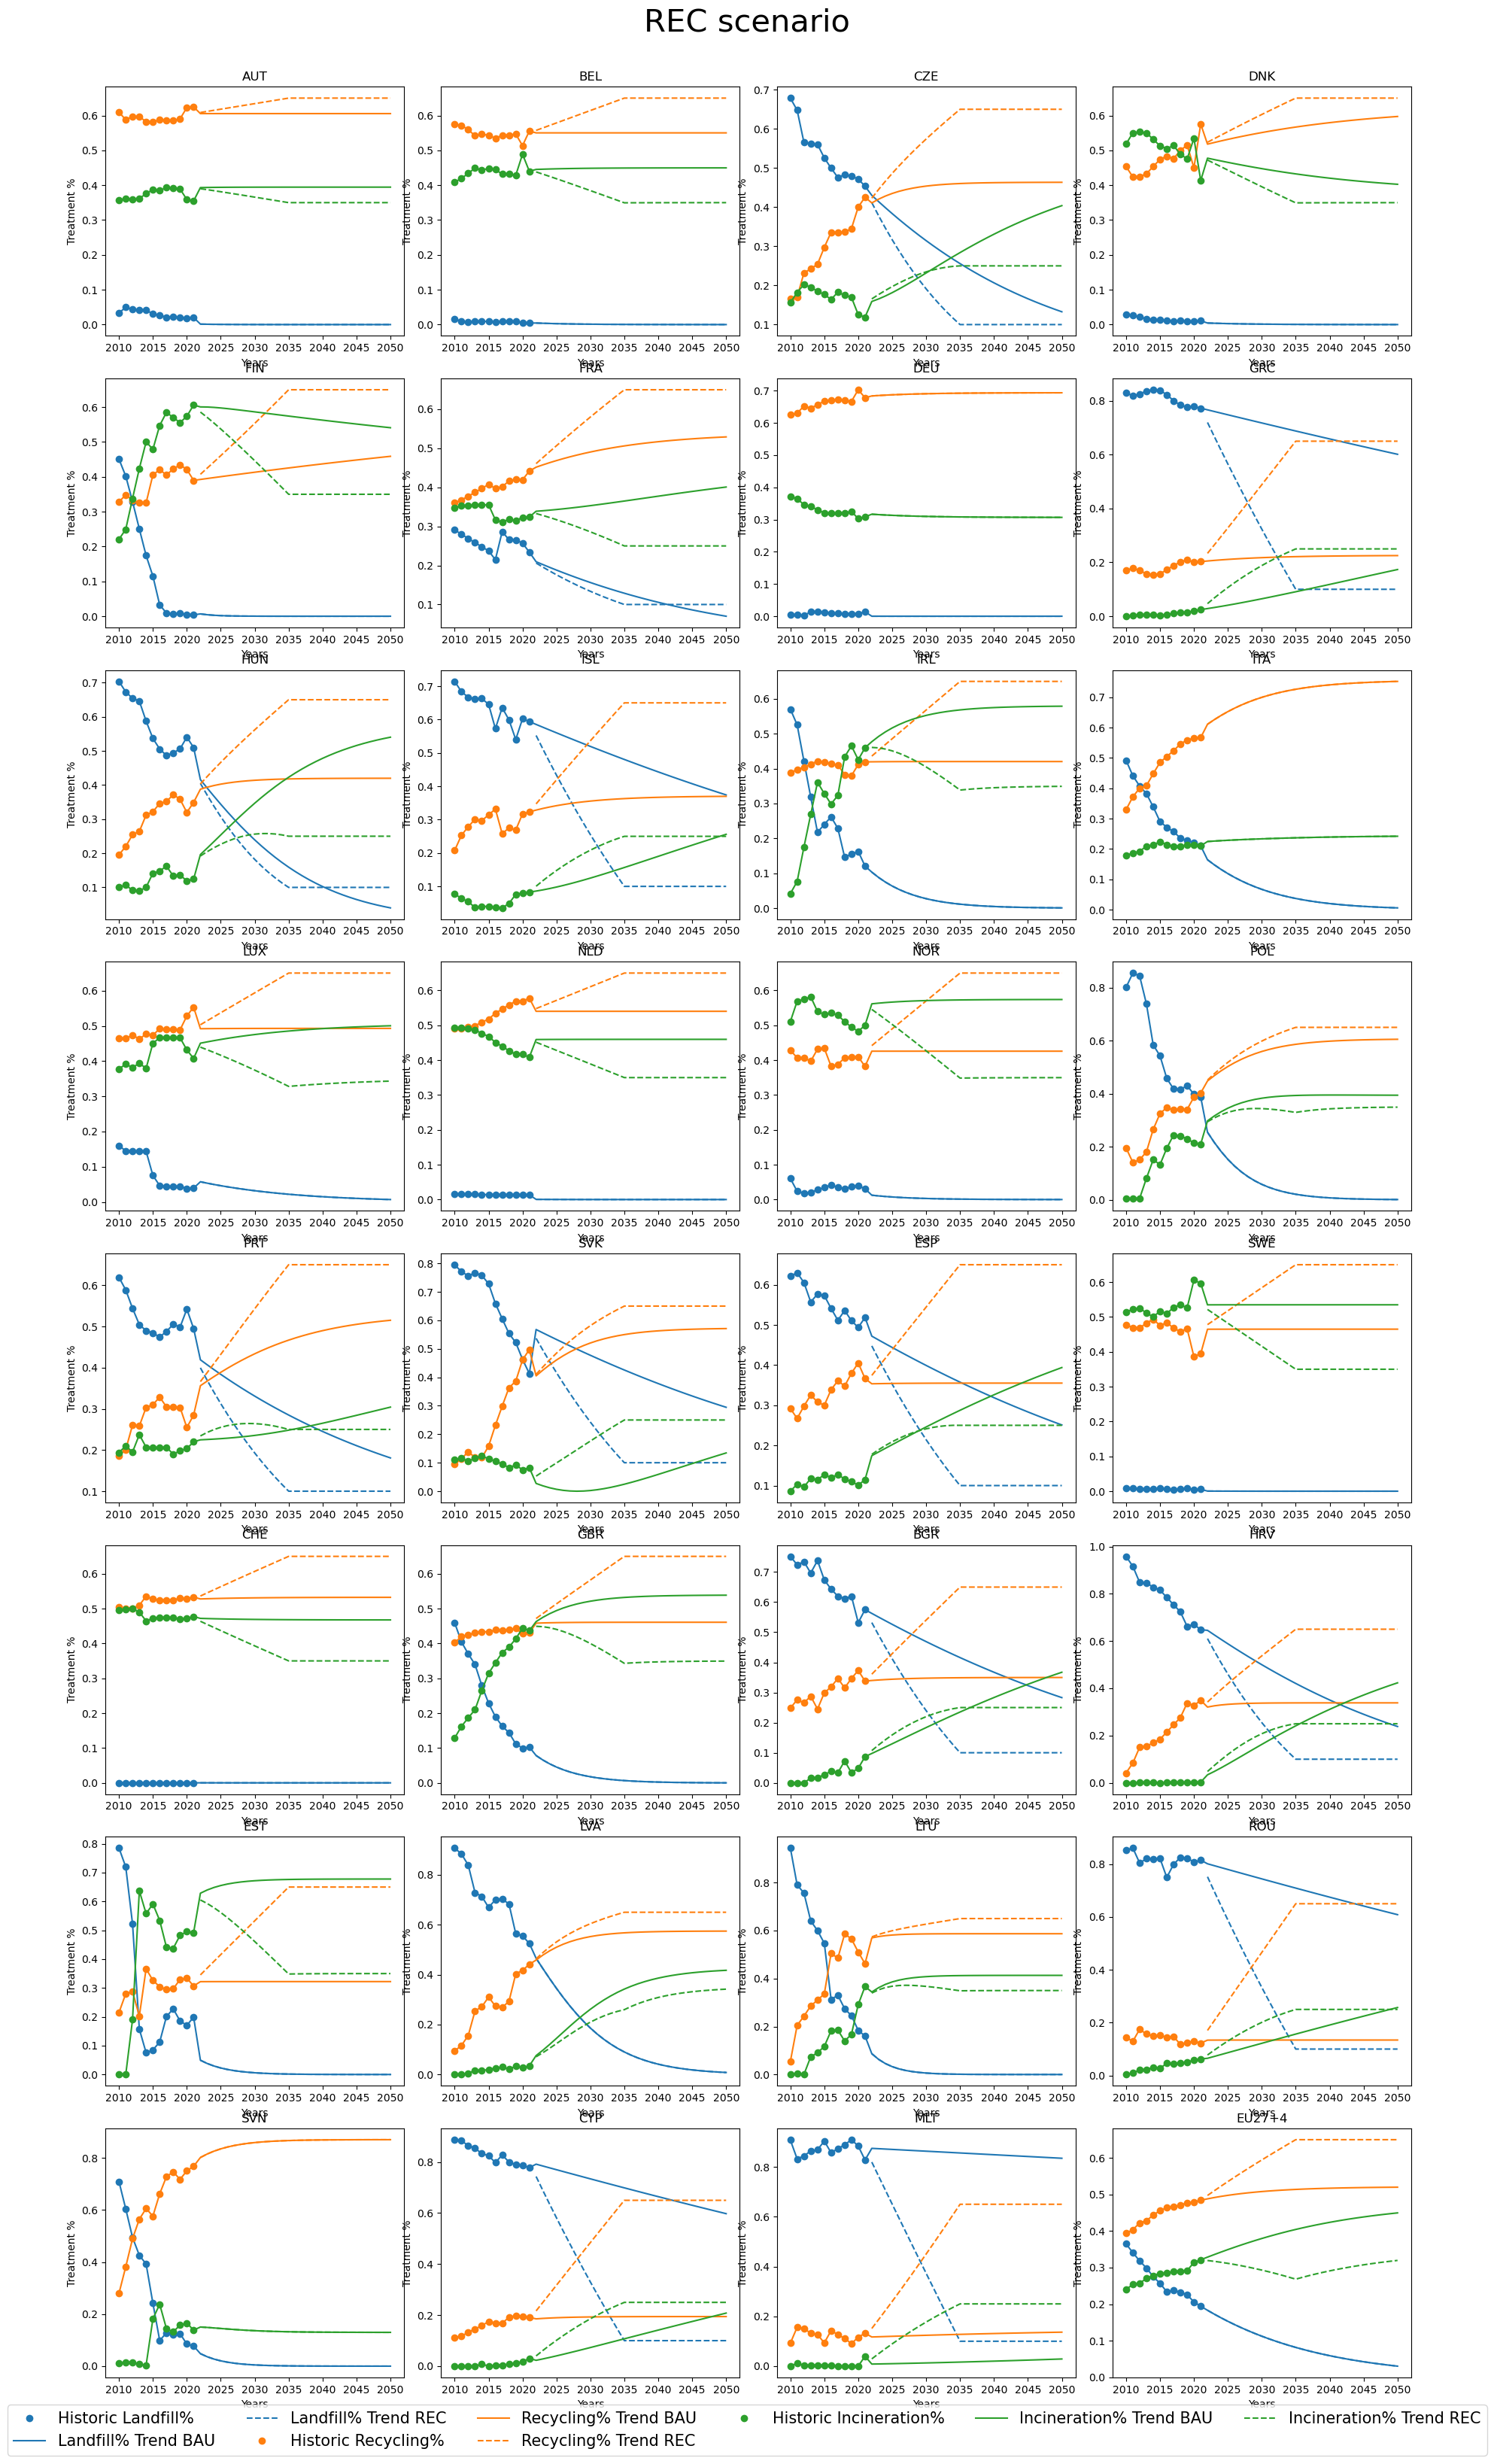

In [9]:
fig, axs = plt.subplots(8, 4, figsize=(20, 35))
axs=axs.flatten()
legend_handles = []
#legend_labels = ['Historic Landfill%','Landfill% Trend BAU','Landfill fit target','Landfill% Trend REC', 'Historic Recycling%', 'Recycling% Trend BAU', 'Recycling fit target','Recycling% Trend REC','Historic Incineration%','Incineration% Trend BAU', 'Incineration fit target','Incineration% Trend REC']
legend_labels = ['Historic Landfill%','Landfill% Trend BAU','Landfill% Trend REC', 'Historic Recycling%', 'Recycling% Trend BAU', 'Recycling% Trend REC','Historic Incineration%','Incineration% Trend BAU', 'Incineration% Trend REC']
i=0
rec_data = rec_data.set_index(['LOCATION','TIME'])
for region in bau_data['LOCATION'].unique():
    #print(region)
    
    reg_bau_data = bau_data.loc[bau_data['LOCATION']==region]
    #print(reg_bau_data)
    
    rec_rcy = get_rec_data(reg_bau_data, 'RCY%', 0.65)
    rec_dis = get_rec_data(reg_bau_data, 'DIS%', 0.10)
    rec_combined = pd.merge(rec_rcy, rec_dis, on='TIME', how='outer')
    rec_inc = get_rec_data(reg_bau_data, 'INC%', rec_data = rec_combined)
    
    
    reg_rec_data = pd.merge(rec_combined, rec_inc, on='TIME', how='outer')
    reg_rec_data['LOCATION'] = region
    
    
    #plotting time series of Landfill %
    lines = axs[i].plot(reg_bau_data.loc[reg_bau_data['TIME']<=2021]['TIME'],reg_bau_data.loc[reg_bau_data['TIME']<=2021]['DIS%'],'o', label='Historic Landfill%', color = '#1f77b4')
    legend_handles.extend(lines)
    x = np.arange(2010,2051)
    lines = axs[i].plot(x, reg_bau_data['DIS%'].loc[reg_bau_data['TIME'].isin(x)],'-',label = 'Landfill% Trend BAU', color = '#1f77b4')
    legend_handles.extend(lines)
       
    lines = axs[i].plot(reg_rec_data.loc[reg_rec_data['TIME']>=2022]['TIME'],reg_rec_data.loc[reg_rec_data['TIME']>=2022]['DIS%'],'--',label = 'Landfill% Trend REC', color = '#1f77b4')
    legend_handles.extend(lines)
    
    #Recycling %
    
    #plotting time series of recycling %
    lines = axs[i].plot(reg_bau_data.loc[reg_bau_data['TIME']<=2021]['TIME'],reg_bau_data.loc[reg_bau_data['TIME']<=2021]['RCY%'],'o', label = 'Historic Recycling%', color='#ff7f0e')
    legend_handles.extend(lines)
    x = np.arange(2010,2051)
    lines = axs[i].plot(x, reg_bau_data['RCY%'].loc[reg_bau_data['TIME'].isin(x)],'-',label = 'Recycling% Trend BAU', color = '#ff7f0e')
    legend_handles.extend(lines)
    lines = axs[i].plot(reg_rec_data.loc[reg_rec_data['TIME']>=2022]['TIME'],reg_rec_data.loc[reg_rec_data['TIME']>=2022]['RCY%'],'--',label = 'Recycling% Trend REC', color = '#ff7f0e')
    legend_handles.extend(lines)
    
    #plotting time series of incineration %
    lines = axs[i].plot(reg_bau_data.loc[reg_bau_data['TIME']<=2021]['TIME'],reg_bau_data.loc[reg_bau_data['TIME']<=2021]['INC%'], 'o', label = 'Historic Incineration%', color = '#2ca02c')
    legend_handles.extend(lines)
    x = np.arange(2010,2051)
    lines = axs[i].plot(x, reg_bau_data['INC%'].loc[reg_bau_data['TIME'].isin(x)],'-',label = 'Incineration% Trend BAU', color = '#2ca02c')
    legend_handles.extend(lines)
       
    lines = axs[i].plot(reg_rec_data.loc[reg_rec_data['TIME']>=2022]['TIME'],reg_rec_data.loc[reg_rec_data['TIME']>=2022]['INC%'],'--',label = 'Incineration% Trend REC', color = '#2ca02c')
    legend_handles.extend(lines)
    
    axs[i].set_title(region)
    
    
    #Update rec_data
    reg_rec_data = reg_rec_data.set_index(['LOCATION','TIME'])
    columns_to_update = ['RCY%', 'DIS%', 'INC%']
    rec_data.update(reg_rec_data[columns_to_update])
    i+=1

#Reset index
rec_data.reset_index(inplace=True)
#Adjust layout to make space for legend and heading
plt.tight_layout(rect=[0, 0, 0.9, 0.93])
#Set axis labels for subplots
for ax in axs:
    ax.set_xlabel('Years')
    ax.set_ylabel('Treatment %')

#Add a common legend for subplots
fig.subplots_adjust(bottom=0.05)
legend_subplot = fig.add_axes([0.1, 0.02, 0.7, 0.02])  
legend_subplot.axis('off')
legend_subplot.legend(legend_handles, legend_labels, loc='center', ncol=6, fontsize=15)

#Add title
title = fig.suptitle('REC scenario', fontsize=30)
title.set_position([0.45, 0.95])
#title.set_y(0.95)
plt.show()

In [ ]:
rec_data["INC_T"] = rec_data['MSW_GEN_T']*rec_data['INC%']
#rec_data.to_csv("data_saved/REC_MSW.csv")
    


## CIR Scenario

In [ ]:
from functions import cir_msw_total


In [ ]:
cir_data = rec_data.copy()
cir_data['Scenario']='CIR'
cir_data = cir_data.set_index(['LOCATION','TIME'])

In [ ]:
for region in rec_data["LOCATION"].unique():
    msw_new = cir_msw_total(bau_data.loc[bau_data['LOCATION']==region], 0.1)
    msw_new['LOCATION'] = region
    msw_new = msw_new.set_index(['LOCATION','TIME'])
    cir_data.update(msw_new['MSW_GEN_T'])

In [ ]:
cir_data = cir_data.reset_index()
cir_data["INC_T"] = cir_data['MSW_GEN_T']*cir_data['INC%']
#cir_data.to_csv("data_saved/CIR_MSW.csv")